<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA/blob/main/RANDOM_FOREST(CLASSIFICATION)_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RANDOM FOREST**

# **CLASSIFICATION**

# 1.LOAD AND DISPLAY THE DATASET

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/BMW_Car_Sales_Classification.csv')
df.head(3)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low


# 2.UNDERSTAND THE DATA TYPES AND SUMMARY

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


# 3.DATA CLEANING

In [ ]:
df.isnull().sum()

,0
Model,0
Year,0
Region,0
Color,0
Fuel_Type,0
Transmission,0
Engine_Size_L,0
Mileage_KM,0
Price_USD,0
Sales_Volume,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# 4.VISUALIZATION

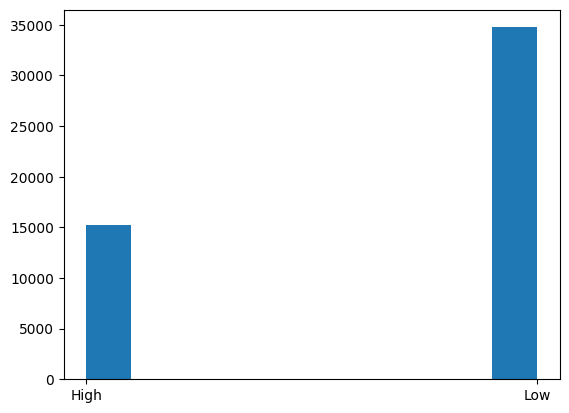

In [ ]:
plt.hist(df['Sales_Classification'])
plt.show()

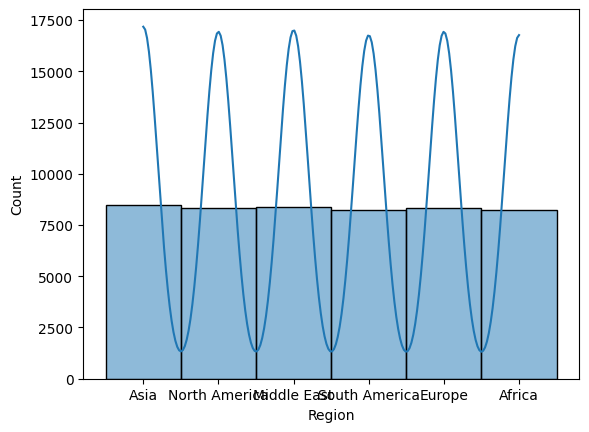

In [ ]:
sns.histplot(df['Region'],kde=True)
plt.show()

# 5.CORRELATION ANALYSIS IN EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [ ]:
print(df['Model'].unique())

['5 Series' 'i8' 'X3' '7 Series' 'M5' '3 Series' 'X1' 'M3' 'X5' 'i3' 'X6']


In [ ]:
print(df['Region'].unique())

['Asia' 'North America' 'Middle East' 'South America' 'Europe' 'Africa']


In [ ]:
print(df['Color'].unique())

['Red' 'Blue' 'Black' 'Silver' 'White' 'Grey']


In [ ]:
print(df['Fuel_Type'].unique())

['Petrol' 'Hybrid' 'Diesel' 'Electric']


In [ ]:
print(df['Transmission'].unique())

['Manual' 'Automatic']


In [ ]:
print(df['Sales_Classification'].unique())

['High' 'Low']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['Model']=le.fit_transform(df['Model'])
df['Region']=le.fit_transform(df['Region'])

In [ ]:
df['Sales_Classification'].replace(['High','Low'],[0,1],inplace=True)
df['Transmission'].replace(['Manual','Automatic'],[0,1],inplace=True)
df['Fuel_Type'].replace(['Petrol','Hybrid','Diesel','Electric'],[0,1,2,3],inplace=True)
df['Color'].replace(['Red','Blue','Black','Silver','White','Grey'],[0,1,2,3,4,5],inplace=True)

/tmp/ipykernel_35478/3914655215.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales_Classification'].replace(['High','Low'],[0,1],inplace=True)
/tmp/ipykernel_35478/3914655215.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sales_Classification'].replace(['High','Low'],[0,1],inplac

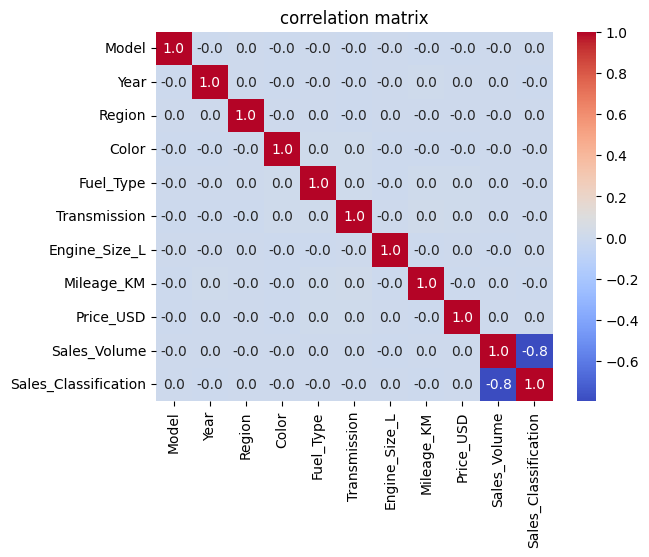

In [ ]:
corr_matrix=df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("correlation matrix")
plt.show()

# 6.OUTLIER CHECKING AND REMOVING

<Axes: >

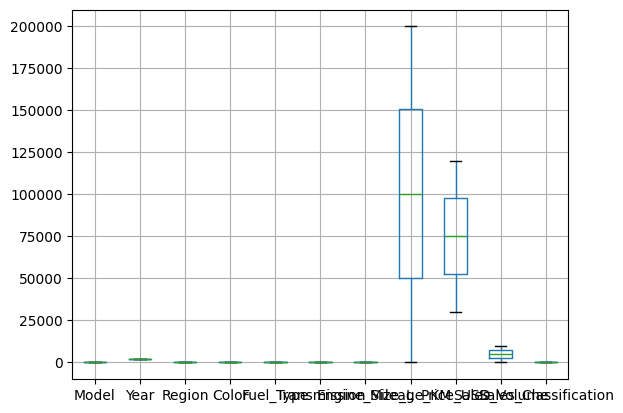

In [ ]:
df.boxplot()

In [ ]:
df.shape

(50000, 11)

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
      continue
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df=df[(df[col] >=lower_bound)& (df[col] <=upper_bound)]
  return df

df_cleaned=remove_outliers_iqr(df,exclude_column='Sales_Classification')
df=df_cleaned

In [ ]:
df.shape

(50000, 11)

# 7.DATA SCALING

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  int64  
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  int64  
 3   Color                 50000 non-null  int64  
 4   Fuel_Type             50000 non-null  int64  
 5   Transmission          50000 non-null  int64  
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 4.2 MB


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['Model','Year','Region','Color','Fuel_Type','Transmission','Engine_Size_L','Mileage_KM','Price_USD','Sales_Volume']

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

# 8.AFTER EDA CAN PREDICT

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['Model','Year','Region','Color','Fuel_Type','Transmission','Engine_Size_L','Mileage_KM','Price_USD','Sales_Volume']]
y=df['Sales_Classification']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Baseline Model Accuracy:{accuracy:.2f}')

Baseline Model Accuracy:1.00


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier

x=df[['Model','Year','Region','Color','Fuel_Type','Transmission','Engine_Size_L','Mileage_KM','Price_USD','Sales_Volume']]
y=df['Sales_Classification']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy=model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:.2f}')

Baseline model accuracy:1.00
